# XGBoost Forecast Model — Training Notebook

Trains a **multi-step direct XGBoost** model and registers it to the MLflow Registry,
ready to be served by **ml-server** (`model_type: xgb`).

**Pipeline**
1. Pull historical load data from the SCADA / NDC API
2. Exploratory data analysis
3. Feature engineering — lag features + cyclic time encodings
4. Time-series cross-validation + hyperparameter search
5. Final training — one XGBoost booster per forecast horizon step
6. Evaluation — MAE / RMSE / MAPE per step and averaged
7. Bundle assembly (`bundle/model/` + `bundle/configuration/cache_config.json`)
8. MLflow experiment logging + model registration + `Production` alias

**Feature convention** (must match `XGBoostAdapter._build_feature_vector_for_inference`):
```
X = [y[t-n_lags], ..., y[t-1],  sin(2π·hour/24), cos(2π·hour/24),
                                  sin(2π·dow/7),   cos(2π·dow/7)]
```

**Bundle layout** (matches `ModelProvider._is_bundle_valid`):
```
bundle/
  configuration/cache_config.json   ← runtime config for ml-server
  model/
    xgb_model.json                  ← manifest {"steps": ["step_0.ubj", ...]}
    step_0.ubj                      ← booster for horizon 0 (next step)
    step_1.ubj                      ← booster for horizon 1
    ...
```

## 0 · Imports

In [1]:
import json
import math
import shutil
import tempfile
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mlflow
import mlflow.xgboost
from mlflow.tracking import MlflowClient
import numpy as np
import pandas as pd
import requests
import xgboost as xgb
from sklearn.model_selection import ParameterSampler

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

print(f'xgboost {xgb.__version__}  |  mlflow {mlflow.__version__}')

xgboost 3.2.0  |  mlflow 3.11.1


## 1 · Configuration

**Edit this cell before every training run.**

In [3]:
# ── SCADA / NDC ──────────────────────────────────────────────────────────────
SCADA_URL = "http://localhost:7080/api/v1/read/archives"

# Archive tag(s) for the forecasting object (one archive → univariate model)
ARCHIVES = ["/root/FP/PROJECT/AKMOLA/Nura_SES/Pgen_sum/archives/out_value"]

# How many days of history to pull for training
TRAIN_HISTORY_DAYS = 90

# ── Time resolution ───────────────────────────────────────────────────────────
STEP_SECONDS = 3600          # seconds per timestep (3600 = hourly)
INPUT_RANGE  = 168           # look-back steps fed to the model at inference
OUTPUT_RANGE = 24            # forecast horizon steps (one booster per step)

# ── Feature engineering ───────────────────────────────────────────────────────
# Lag window used during training; must be <= INPUT_RANGE.
# Total features per sample = N_LAGS + 4  (the 4 cyclic time features).
# This value is stored in the booster and used by XGBoostAdapter at inference.
N_LAGS = 168

# ── MLflow ────────────────────────────────────────────────────────────────────
MLFLOW_TRACKING_URI = "http://localhost:5050"   # or "sqlite:///mlflow.db"
EXPERIMENT_NAME     = "xgb/AKMOLA/Nura_SES/power_gen" # one experiment per object
REGISTERED_MODEL    = "xgb_AKMOLA_Nura_SES_power_gen"  # MLflow registered-model name
REGISTER_ALIAS      = "Test"               # alias assigned after training

# ── Fallback for inference failures ───────────────────────────────────────────
FALLBACK_MODEL = "naive"   # "none" | "naive" | "ar" | "prophet"

# ── Cross-validation ──────────────────────────────────────────────────────────
N_CV_SPLITS   = 5     # number of walk-forward CV folds
N_TUNE_ITER   = 30    # random HP combinations to try during tuning
TUNE_ON_STEP  = 0     # horizon step index (0 = next step) used for HP tuning

# ── Output directory (temporary; final artifacts go to MLflow) ────────────────
BUNDLE_DIR = Path("bundle_output")   # created / overwritten each run

print('Configuration loaded')
print(f'  archives      : {ARCHIVES}')
print(f'  step          : {STEP_SECONDS}s  input_range={INPUT_RANGE}  output_range={OUTPUT_RANGE}')
print(f'  n_lags        : {N_LAGS}  →  total features = {N_LAGS + 4}')
print(f'  MLflow        : {MLFLOW_TRACKING_URI}  experiment={EXPERIMENT_NAME}')

Configuration loaded
  archives      : ['/root/FP/PROJECT/AKMOLA/Nura_SES/Pgen_sum/archives/out_value']
  step          : 3600s  input_range=168  output_range=24
  n_lags        : 168  →  total features = 172
  MLflow        : http://localhost:5050  experiment=xgb/AKMOLA/Nura_SES/power_gen


## 2 · Data Loading from SCADA

Calls the same endpoint the inference worker uses (`historical_client.py`).
Falls back to synthetic data if the endpoint is unavailable.

In [4]:
def fetch_scada(
    url: str,
    archives: list[str],
    step_seconds: int,
    days: int,
    request_overrides: dict | None = None,
) -> dict[str, list]:
    """
    POST to the SCADA / NDC API and return the raw payload.

    Response shape: {archive_name: [[timestamp_ms, value], ...]}
    Matches the format expected by HistoricalDataClient.validate_response_payload.
    """
    now   = datetime.now(timezone.utc).replace(minute=0, second=0, microsecond=0)
    to_ms = int(now.timestamp() * 1000)
    from_ms = int((now - timedelta(days=days)).timestamp() * 1000)

    body: dict = {
        "from"   : from_ms,
        "to"     : to_ms,
        "archive": archives,
        "step"   : step_seconds,
    }
    if request_overrides:
        body.update(request_overrides)

    resp = requests.post(url, json=body, timeout=60)
    resp.raise_for_status()
    return resp.json()


def make_stub_payload(
    archives: list[str],
    step_seconds: int,
    days: int,
    seed: int = 42,
) -> dict[str, list]:
    """Deterministic synthetic series — used when SCADA is unavailable."""
    rng   = np.random.default_rng(seed)
    now   = datetime.now(timezone.utc).replace(minute=0, second=0, microsecond=0)
    to_ms = int(now.timestamp() * 1000)
    n     = int(days * 86400 / step_seconds)
    step_ms = step_seconds * 1000
    ts    = np.arange(to_ms - n * step_ms, to_ms, step_ms)

    payload: dict = {}
    for i, name in enumerate(archives):
        base     = 400.0 + i * 50.0
        hourly   = np.sin(2 * np.pi * np.arange(n) / 24) * 40
        weekly   = np.sin(2 * np.pi * np.arange(n) / (24 * 7)) * 20
        noise    = rng.normal(0, 5, n)
        values   = base + hourly + weekly + noise
        payload[name] = [[int(t), round(float(v), 3)] for t, v in zip(ts, values)]
    return payload


# ── Fetch ─────────────────────────────────────────────────────────────────────
USE_STUB = False   # set True to work offline

try:
    if USE_STUB:
        raise RuntimeError('stub mode requested')
    raw_payload = fetch_scada(SCADA_URL, ARCHIVES, STEP_SECONDS, TRAIN_HISTORY_DAYS)
    print(f'SCADA OK — {len(raw_payload)} archive(s)')
except Exception as e:
    print(f'SCADA unavailable ({e}); using synthetic stub')
    raw_payload = make_stub_payload(ARCHIVES, STEP_SECONDS, TRAIN_HISTORY_DAYS)

# ── Parse into DataFrame ──────────────────────────────────────────────────────
frames = []
for arch, series in raw_payload.items():
    ts  = [pt[0] for pt in series]
    val = [pt[1] for pt in series]
    df  = pd.DataFrame({'ts_ms': ts, arch: val})
    frames.append(df.set_index('ts_ms'))

data = frames[0] if len(frames) == 1 else frames[0].join(frames[1:], how='outer')
data.index = pd.to_datetime(data.index, unit='ms', utc=True)
data = data.sort_index()

# Use the first (or only) archive as the target series
TARGET_COL = data.columns[0]
series_raw = data[TARGET_COL].copy()

print(f'\nTarget column : {TARGET_COL}')
print(f'Points        : {len(series_raw)}  ({series_raw.index[0]}  →  {series_raw.index[-1]})')
print(f'Missing       : {series_raw.isna().sum()} ({series_raw.isna().mean():.1%})')
print(series_raw.describe().to_string())

SCADA OK — 1 archive(s)

Target column : /root/FP/PROJECT/AKMOLA/Nura_SES/Pgen_sum/archives/out_value
Points        : 2160  (2026-02-26 12:00:00+00:00  →  2026-05-27 11:00:00+00:00)
Missing       : 91 (4.2%)
count    2069.000000
mean       18.783693
std        29.148548
min        -0.158000
25%        -0.111000
50%        -0.087000
75%        31.334999
max        90.486000


## 3 · Exploratory Data Analysis

/var/folders/z9/_xmzk2xd65b6z8w_nqdgdbkm0000gn/T/ipykernel_85993/1246909608.py:10: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last7 = series_raw.last('7D')


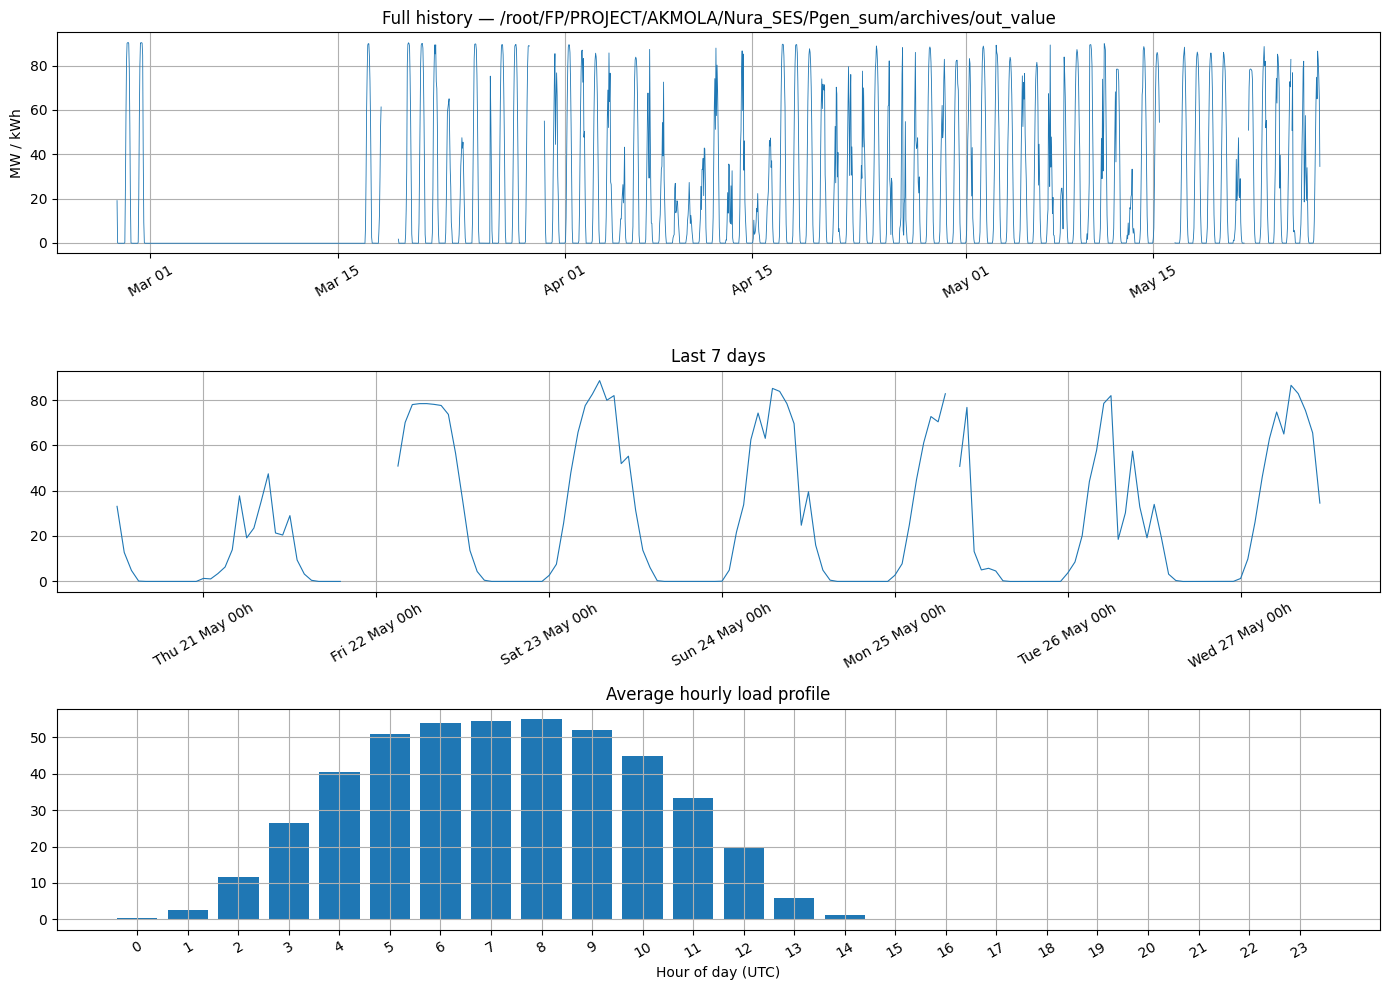

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Full series
axes[0].plot(series_raw.index, series_raw.values, lw=0.6)
axes[0].set_title(f'Full history — {TARGET_COL}')
axes[0].set_ylabel('MW / kWh')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Last 7 days
last7 = series_raw.last('7D')
axes[1].plot(last7.index, last7.values, lw=0.8)
axes[1].set_title('Last 7 days')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b %Hh'))

# Hourly average profile
hourly_profile = series_raw.groupby(series_raw.index.hour).mean()
axes[2].bar(hourly_profile.index, hourly_profile.values, width=0.8)
axes[2].set_title('Average hourly load profile')
axes[2].set_xlabel('Hour of day (UTC)')
axes[2].set_xticks(range(24))

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

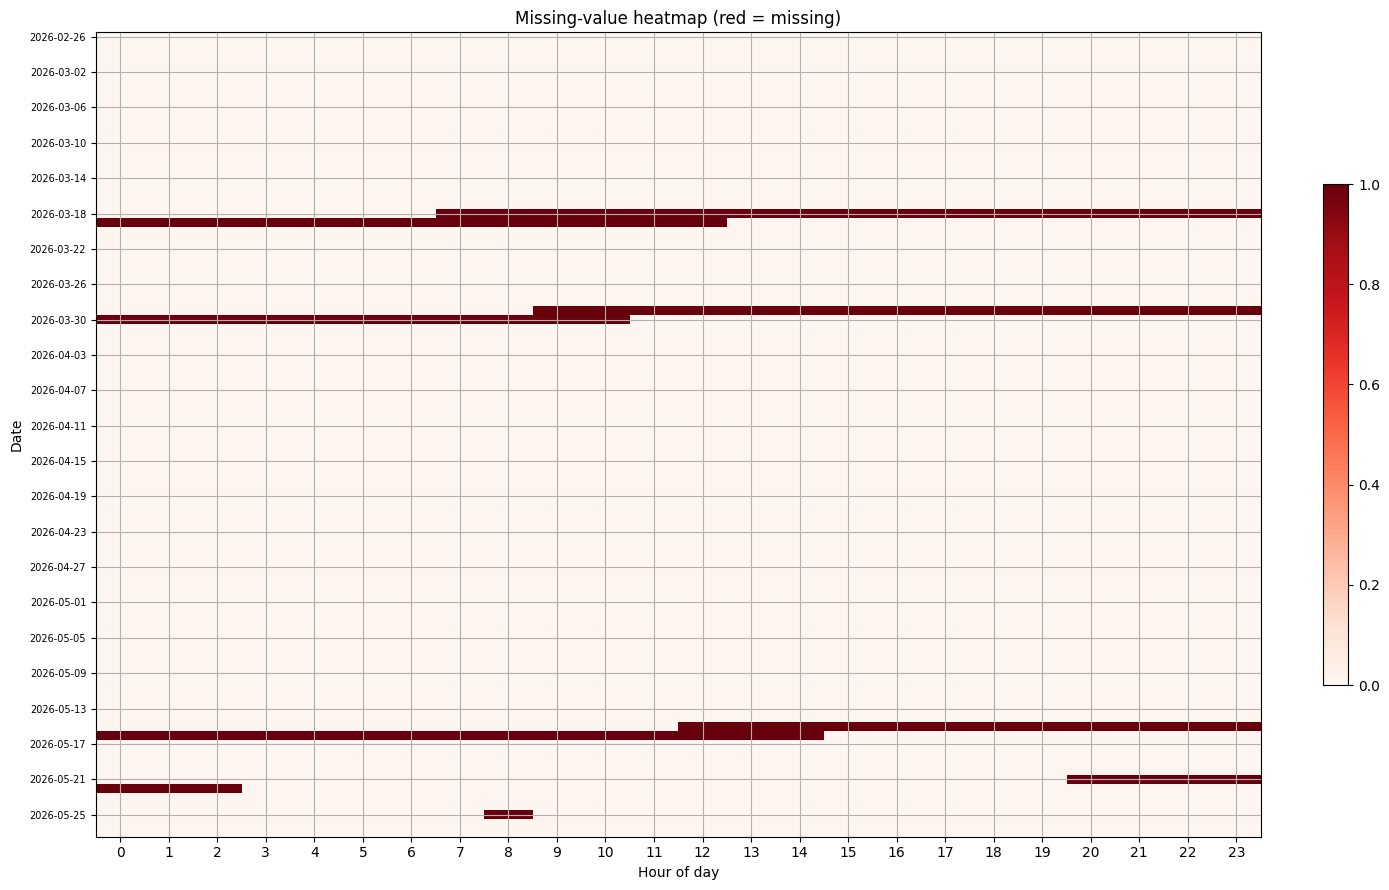

Total missing: 91 / 2160 (4.21%)


In [6]:
# Missing-value heatmap (days × hours)
sr = series_raw.copy()
sr_df = pd.DataFrame({
    'date': sr.index.date,
    'hour': sr.index.hour,
    'missing': sr.isna().astype(int),
})
pivot = sr_df.pivot_table(index='date', columns='hour', values='missing', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(14, max(3, len(pivot) // 10)))
im = ax.imshow(pivot.values, aspect='auto', cmap='Reds', vmin=0, vmax=1)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Date')
ax.set_title('Missing-value heatmap (red = missing)')
ax.set_xticks(range(24))
step_label = max(1, len(pivot) // 20)
ax.set_yticks(range(0, len(pivot), step_label))
ax.set_yticklabels([str(d) for d in pivot.index[::step_label]], fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.show()

total_missing = sr.isna().sum()
print(f'Total missing: {total_missing} / {len(sr)} ({total_missing / len(sr):.2%})')

## 4 · Feature Engineering

The feature vector **must** match `XGBoostAdapter._build_feature_vector_for_inference`:

```python
X[i] = [y[i - N_LAGS], ..., y[i-1],
         sin(2π·hour/24), cos(2π·hour/24),
         sin(2π·dow/7),   cos(2π·dow/7)]
```

Targets use the **multi-step direct** strategy:
```
Y[i, h] = y[i + h]   for h in 0..OUTPUT_RANGE-1
```
One XGBoost booster is trained per horizon step `h`.

In [7]:
def interpolate_series(values: np.ndarray) -> np.ndarray:
    """Linear interpolation of NaN gaps (same approach as HistoricalDataClient)."""
    s = pd.Series(values, dtype=float)
    s = s.interpolate(method='linear', limit_direction='both')
    return s.values


def build_dataset(
    values: np.ndarray,
    timestamps_ms: np.ndarray,
    n_lags: int,
    output_range: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Build the training feature matrix X and target matrix Y.

    Parameters
    ----------
    values        : 1-D array of target values (NaN-free)
    timestamps_ms : 1-D array of epoch-ms timestamps, same length as values
    n_lags        : number of lag values (look-back window)
    output_range  : number of forecast horizon steps

    Returns
    -------
    X : (n_samples, n_lags + 4)  — feature matrix
    Y : (n_samples, output_range) — target matrix
    """
    n = len(values)
    n_samples = n - n_lags - output_range + 1
    if n_samples <= 0:
        raise ValueError(
            f'Not enough data: need >{n_lags + output_range} points, got {n}'
        )

    X = np.empty((n_samples, n_lags + 4), dtype=np.float32)
    Y = np.empty((n_samples, output_range), dtype=np.float32)

    for i in range(n_samples):
        # Lag features: the last n_lags values before the prediction point
        X[i, :n_lags] = values[i : i + n_lags]

        # Cyclic time features for the *prediction* timestamp
        ts_next_ms = int(timestamps_ms[i + n_lags])
        dt = datetime.fromtimestamp(ts_next_ms / 1000, tz=timezone.utc)
        hour = float(dt.hour)
        dow  = float(dt.weekday())

        X[i, n_lags + 0] = math.sin(2 * math.pi * hour / 24.0)
        X[i, n_lags + 1] = math.cos(2 * math.pi * hour / 24.0)
        X[i, n_lags + 2] = math.sin(2 * math.pi * dow  / 7.0)
        X[i, n_lags + 3] = math.cos(2 * math.pi * dow  / 7.0)

        # Targets: next output_range values
        Y[i] = values[i + n_lags : i + n_lags + output_range]

    return X, Y


# ── Prepare clean series ──────────────────────────────────────────────────────
values_clean = interpolate_series(series_raw.values)
timestamps_ms = series_raw.index.astype(np.int64) // 10**6   # ns → ms

X_all, Y_all = build_dataset(values_clean, timestamps_ms, N_LAGS, OUTPUT_RANGE)

print(f'Feature matrix X : {X_all.shape}  (samples × features)')
print(f'Target matrix  Y : {Y_all.shape}  (samples × horizon steps)')
print(f'NaN in X         : {np.isnan(X_all).sum()}')
print(f'NaN in Y         : {np.isnan(Y_all).sum()}')

Feature matrix X : (1969, 172)  (samples × features)
Target matrix  Y : (1969, 24)  (samples × horizon steps)
NaN in X         : 0
NaN in Y         : 0


## 5 · Train / Validation Split

Walk-forward cross-validation — the validation window always follows the training window
in time, never the reverse.

CV folds for tuning : 4
Train samples       : 1674
Test  samples       : 295


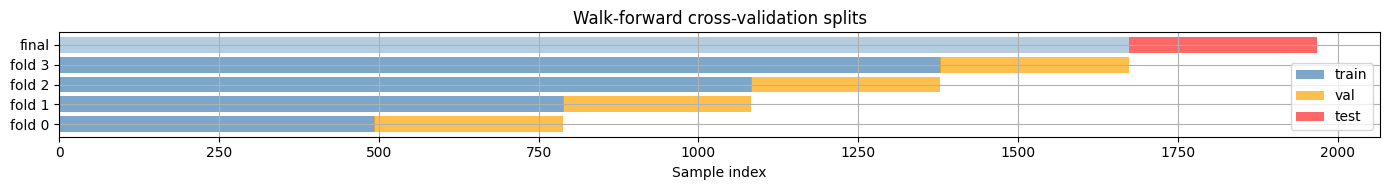

In [8]:
def walk_forward_splits(
    n_samples: int,
    n_splits: int,
    val_frac: float = 0.15,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """
    Walk-forward splits.  Each fold: train on [0..split_end], validate on next val_size.

    Returns list of (train_idx, val_idx) tuples.
    """
    val_size   = max(1, int(n_samples * val_frac))
    min_train  = n_samples - n_splits * val_size
    if min_train <= 0:
        raise ValueError('Too many splits for the available data; reduce N_CV_SPLITS.')

    splits = []
    for k in range(n_splits):
        end_train = min_train + k * val_size
        end_val   = end_train + val_size
        train_idx = np.arange(0, end_train)
        val_idx   = np.arange(end_train, min(end_val, n_samples))
        if len(val_idx) == 0:
            break
        splits.append((train_idx, val_idx))
    return splits


splits = walk_forward_splits(len(X_all), N_CV_SPLITS)

# Keep final test fold (last split) separate for unbiased evaluation
train_idx_full, test_idx = splits[-1]
cv_splits = splits[:-1]      # folds used for HP tuning

X_train, Y_train = X_all[train_idx_full], Y_all[train_idx_full]
X_test,  Y_test  = X_all[test_idx],       Y_all[test_idx]

print(f'CV folds for tuning : {len(cv_splits)}')
print(f'Train samples       : {len(X_train)}')
print(f'Test  samples       : {len(X_test)}')

# Visualise splits
fig, ax = plt.subplots(figsize=(14, 2))
for fold_i, (tr, vl) in enumerate(splits[:-1]):
    ax.barh(fold_i, len(tr), color='steelblue', alpha=0.7, label='train' if fold_i == 0 else '')
    ax.barh(fold_i, len(vl), left=tr[-1], color='orange', alpha=0.7, label='val' if fold_i == 0 else '')
ax.barh(len(splits)-1, len(train_idx_full), color='steelblue', alpha=0.4)
ax.barh(len(splits)-1, len(test_idx), left=train_idx_full[-1], color='red', alpha=0.6, label='test')
ax.set_xlabel('Sample index')
ax.set_yticks(range(len(splits)))
ax.set_yticklabels([f'fold {i}' for i in range(len(splits)-1)] + ['final'])
ax.set_title('Walk-forward cross-validation splits')
ax.legend()
plt.tight_layout()
plt.show()

## 6 · Hyperparameter Tuning

Randomised search over the CV folds, tuning on the **first** forecast horizon step
(`TUNE_ON_STEP = 0`). The best params are reused for all output steps.

In [9]:
PARAM_GRID = {
    'max_depth'        : [3, 4, 5, 6, 7],
    'eta'              : [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight' : [1, 3, 5, 10],
    'gamma'            : [0.0, 0.1, 0.3, 0.5],
    'lambda'           : [0.5, 1.0, 2.0, 5.0],
    'alpha'            : [0.0, 0.1, 0.5, 1.0],
}

FIXED_PARAMS = {
    'objective'       : 'reg:squarederror',
    'eval_metric'     : 'rmse',
    'tree_method'     : 'hist',
    'seed'            : 42,
    'nthread'         : -1,
    'verbosity'       : 0,
}
NUM_BOOST_ROUND = 300
EARLY_STOPPING  = 20


def cv_rmse_for_params(
    params: dict,
    X: np.ndarray,
    y: np.ndarray,
    splits: list[tuple],
) -> float:
    """Average RMSE over walk-forward folds for a single horizon step."""
    scores = []
    for tr_idx, vl_idx in splits:
        dtrain = xgb.DMatrix(X[tr_idx], label=y[tr_idx])
        dval   = xgb.DMatrix(X[vl_idx], label=y[vl_idx])
        bst    = xgb.train(
            {**FIXED_PARAMS, **params},
            dtrain,
            num_boost_round=NUM_BOOST_ROUND,
            evals=[(dval, 'val')],
            early_stopping_rounds=EARLY_STOPPING,
            verbose_eval=False,
        )
        preds  = bst.predict(dval)
        rmse   = float(np.sqrt(np.mean((preds - y[vl_idx]) ** 2)))
        scores.append(rmse)
    return float(np.mean(scores))


# ── Tune on the first horizon step ───────────────────────────────────────────
y_tune = Y_all[:, TUNE_ON_STEP]

rng    = np.random.RandomState(42)
sampler = list(ParameterSampler(PARAM_GRID, n_iter=N_TUNE_ITER, random_state=rng))

results = []
for i, candidate in enumerate(sampler):
    score = cv_rmse_for_params(candidate, X_all, y_tune, cv_splits)
    results.append({'params': candidate, 'cv_rmse': score})
    print(f'  [{i+1:2d}/{N_TUNE_ITER}] RMSE={score:.3f}  params={candidate}')

best = min(results, key=lambda r: r['cv_rmse'])
BEST_PARAMS = {**FIXED_PARAMS, **best['params']}

print(f'\n✓ Best CV RMSE = {best["cv_rmse"]:.3f}')
print(f'  Best params  = {best["params"]}')

  [ 1/30] RMSE=11.572  params={'subsample': 0.9, 'min_child_weight': 10, 'max_depth': 5, 'lambda': 5.0, 'gamma': 0.0, 'eta': 0.15, 'colsample_bytree': 0.8, 'alpha': 0.5}
  [ 2/30] RMSE=12.269  params={'subsample': 0.8, 'min_child_weight': 3, 'max_depth': 6, 'lambda': 0.5, 'gamma': 0.5, 'eta': 0.03, 'colsample_bytree': 0.6, 'alpha': 1.0}
  [ 3/30] RMSE=11.745  params={'subsample': 0.8, 'min_child_weight': 5, 'max_depth': 4, 'lambda': 5.0, 'gamma': 0.1, 'eta': 0.15, 'colsample_bytree': 0.9, 'alpha': 0.5}
  [ 4/30] RMSE=13.206  params={'subsample': 1.0, 'min_child_weight': 5, 'max_depth': 7, 'lambda': 0.5, 'gamma': 0.5, 'eta': 0.15, 'colsample_bytree': 0.6, 'alpha': 0.5}
  [ 5/30] RMSE=11.665  params={'subsample': 1.0, 'min_child_weight': 10, 'max_depth': 6, 'lambda': 2.0, 'gamma': 0.5, 'eta': 0.05, 'colsample_bytree': 0.8, 'alpha': 0.5}
  [ 6/30] RMSE=11.872  params={'subsample': 0.9, 'min_child_weight': 3, 'max_depth': 6, 'lambda': 2.0, 'gamma': 0.5, 'eta': 0.05, 'colsample_bytree': 0.7

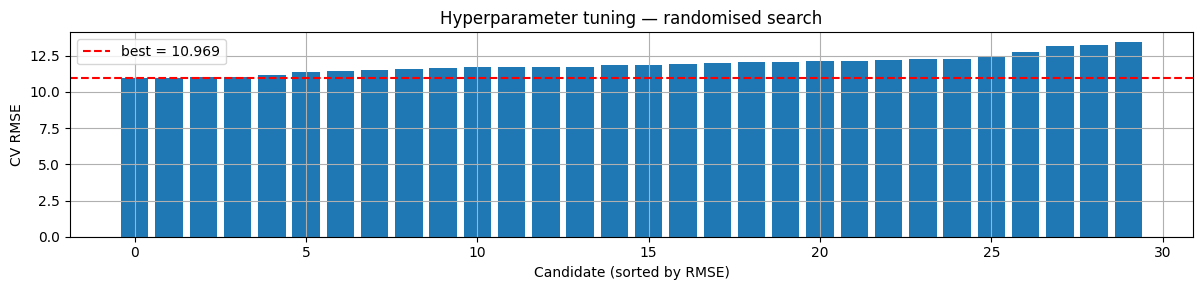

In [10]:
# Plot tuning results
scores_sorted = sorted(results, key=lambda r: r['cv_rmse'])
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(len(scores_sorted)), [r['cv_rmse'] for r in scores_sorted], width=0.8)
ax.axhline(best['cv_rmse'], color='red', ls='--', lw=1.5, label=f'best = {best["cv_rmse"]:.3f}')
ax.set_xlabel('Candidate (sorted by RMSE)')
ax.set_ylabel('CV RMSE')
ax.set_title('Hyperparameter tuning — randomised search')
ax.legend()
plt.tight_layout()
plt.show()

## 7 · Final Training — Multi-Step Direct Strategy

One XGBoost booster trained per forecast horizon step h ∈ {0, …, OUTPUT_RANGE−1}.
Training uses the full `X_train / Y_train`; validation on `X_test / Y_test`.

In [11]:
boosters: dict[int, xgb.Booster] = {}   # {step_index: booster}
best_rounds: list[int] = []

dtrain_full = {}
dtest_full  = {}

for h in range(OUTPUT_RANGE):
    y_tr = Y_train[:, h]
    y_te = Y_test[:, h]

    dtrain = xgb.DMatrix(X_train, label=y_tr)
    dtest  = xgb.DMatrix(X_test,  label=y_te)

    bst = xgb.train(
        BEST_PARAMS,
        dtrain,
        num_boost_round=NUM_BOOST_ROUND,
        evals=[(dtest, 'test')],
        early_stopping_rounds=EARLY_STOPPING,
        verbose_eval=False,
    )
    boosters[h] = bst
    best_rounds.append(bst.best_iteration)

    dtrain_full[h] = dtrain
    dtest_full[h]  = dtest

    if h % 4 == 0 or h == OUTPUT_RANGE - 1:
        print(f'  step {h:2d}/{OUTPUT_RANGE-1}  best_round={bst.best_iteration}')

print(f'\n✓ All {OUTPUT_RANGE} boosters trained.')
print(f'  Avg best_round : {np.mean(best_rounds):.1f}')

  step  0/23  best_round=168
  step  4/23  best_round=238
  step  8/23  best_round=223
  step 12/23  best_round=228
  step 16/23  best_round=242
  step 20/23  best_round=174
  step 23/23  best_round=185

✓ All 24 boosters trained.
  Avg best_round : 211.5


## 8 · Evaluation

In [12]:
def mape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1.0) -> float:
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return float('nan')
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


metrics_per_step = []
Y_pred = np.zeros_like(Y_test)

for h in range(OUTPUT_RANGE):
    bst    = boosters[h]
    preds  = bst.predict(dtest_full[h])
    Y_pred[:, h] = preds
    y_true = Y_test[:, h]

    mae_h  = float(np.mean(np.abs(preds - y_true)))
    rmse_h = float(np.sqrt(np.mean((preds - y_true) ** 2)))
    mape_h = mape(y_true, preds)
    metrics_per_step.append({'step': h, 'MAE': mae_h, 'RMSE': rmse_h, 'MAPE_%': mape_h})

metrics_df = pd.DataFrame(metrics_per_step).set_index('step')

# Aggregate
mean_mae  = metrics_df['MAE'].mean()
mean_rmse = metrics_df['RMSE'].mean()
mean_mape = metrics_df['MAPE_%'].mean()

print(f'Test-set metrics (mean over {OUTPUT_RANGE} steps)')
print(f'  MAE   = {mean_mae:.3f}')
print(f'  RMSE  = {mean_rmse:.3f}')
print(f'  MAPE  = {mean_mape:.2f}%')
print()
print(metrics_df.to_string())

Test-set metrics (mean over 24 steps)
  MAE   = 9.969
  RMSE  = 15.158
  MAPE  = 57.19%

            MAE       RMSE     MAPE_%
step                                 
0      5.118589   8.471345  33.657814
1      7.004184  11.004318  42.588131
2      7.928083  12.197578  47.931282
3      9.329474  14.167163  52.553280
4      9.718935  14.573596  54.277611
5      9.853200  14.880506  56.345802
6      9.705171  14.820631  54.741074
7      9.967987  15.190306  56.747200
8     10.145618  15.332282  60.174953
9     10.453074  15.869041  59.889500
10    10.381500  15.584931  59.307869
11    10.268415  15.400042  57.483627
12    10.586442  16.001919  59.421509
13    10.326701  15.748803  57.904232
14    10.382449  16.002165  62.014233
15    10.364806  15.845288  62.474571
16    10.728966  16.277721  59.159721
17    11.142302  16.835360  63.607033
18    10.820761  16.482582  62.383133
19    10.771222  16.290588  58.426517
20    10.851340  16.347904  62.855232
21    10.830031  16.447987  61.753380

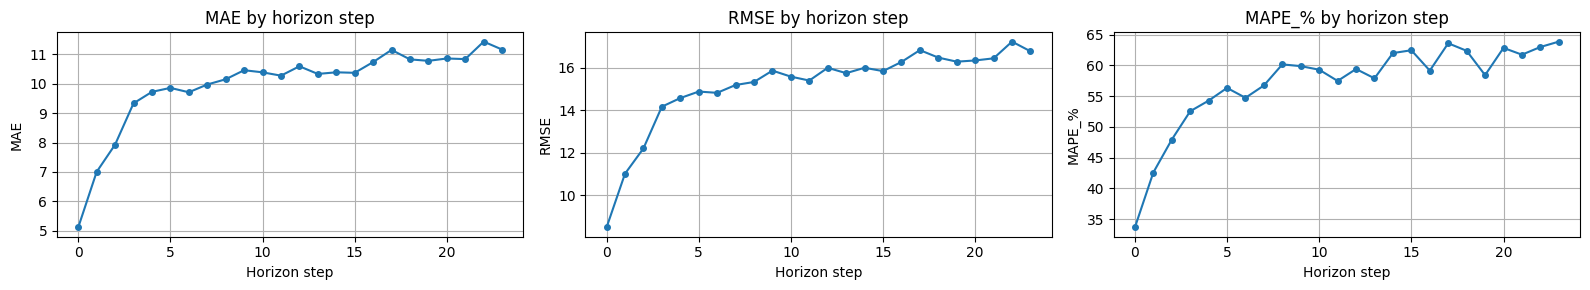

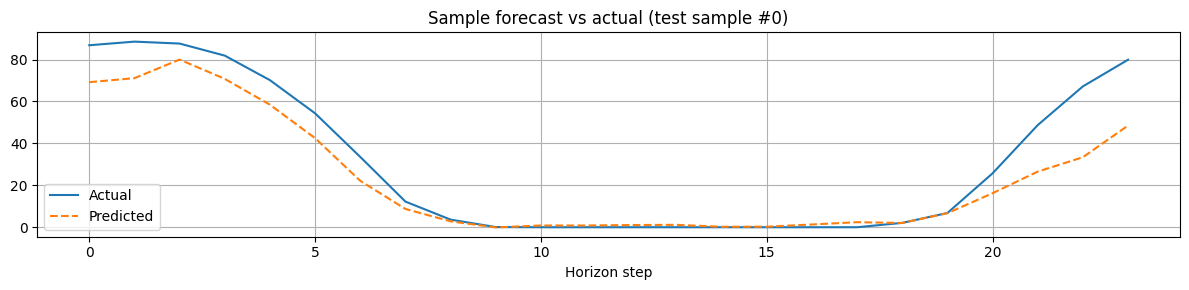

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3))
for ax, col in zip(axes, ['MAE', 'RMSE', 'MAPE_%']):
    ax.plot(metrics_df.index, metrics_df[col], marker='o', ms=4)
    ax.set_xlabel('Horizon step')
    ax.set_ylabel(col)
    ax.set_title(f'{col} by horizon step')
plt.tight_layout()
plt.show()

# Scatter: actual vs predicted for one sample
sample_idx = 0
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(Y_test[sample_idx],  label='Actual',    lw=1.5)
ax.plot(Y_pred[sample_idx],  label='Predicted', lw=1.5, ls='--')
ax.set_title(f'Sample forecast vs actual (test sample #{sample_idx})')
ax.set_xlabel('Horizon step')
ax.legend()
plt.tight_layout()
plt.show()

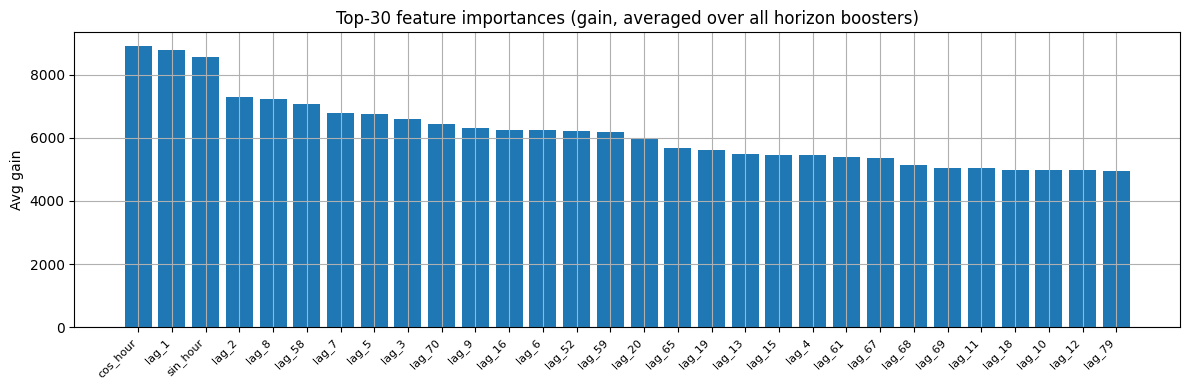

In [14]:
# Feature importance (averaged over all horizon boosters)
importance_sum = np.zeros(N_LAGS + 4, dtype=float)
for bst in boosters.values():
    scores = bst.get_score(importance_type='gain')
    for feat_name, score in scores.items():
        # XGBoost names features f0, f1, ... by default
        idx = int(feat_name[1:])
        importance_sum[idx] += score
importance_avg = importance_sum / OUTPUT_RANGE

# Map feature names
feat_names = [f'lag_{N_LAGS - i}' for i in range(N_LAGS)] + [
    'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow'
]

# Show top-30 features
top_k = min(30, len(feat_names))
top_idx = np.argsort(importance_avg)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(top_k), importance_avg[top_idx])
ax.set_xticks(range(top_k))
ax.set_xticklabels([feat_names[i] for i in top_idx], rotation=45, ha='right', fontsize=8)
ax.set_title(f'Top-{top_k} feature importances (gain, averaged over all horizon boosters)')
ax.set_ylabel('Avg gain')
plt.tight_layout()
plt.show()

## 9 · Bundle Assembly

Creates the canonical layout expected by `ModelProvider` and `init_model`:
```
bundle/
  configuration/cache_config.json
  model/
    xgb_model.json          ← {"steps": ["step_0.ubj", ...]}
    step_0.ubj
    step_1.ubj
    ...
```

In [15]:
# ── Recreate output directory ─────────────────────────────────────────────────
if BUNDLE_DIR.exists():
    shutil.rmtree(BUNDLE_DIR)

bundle_model_dir = BUNDLE_DIR / 'bundle' / 'model'
bundle_cfg_dir   = BUNDLE_DIR / 'bundle' / 'configuration'
bundle_model_dir.mkdir(parents=True)
bundle_cfg_dir.mkdir(parents=True)

# ── Save per-step boosters ───────────────────────────────────────────────────
step_files = []
for h, bst in sorted(boosters.items()):
    fname = f'step_{h}.ubj'
    bst.save_model(str(bundle_model_dir / fname))
    step_files.append(fname)

# ── Save manifest ─────────────────────────────────────────────────────────────
manifest = {'steps': step_files}
with open(bundle_model_dir / 'xgb_model.json', 'w') as f:
    json.dump(manifest, f, indent=2)

# ── Build cache_config.json ───────────────────────────────────────────────────
cache_config = {
    'model_type'   : 'xgb',
    'step'         : STEP_SECONDS,
    'input_range'  : INPUT_RANGE,
    'output_range' : OUTPUT_RANGE,
    'fallback'     : FALLBACK_MODEL,
    'sources': {
        'historical_data': {
            'type': 'historical_data',
            'url' : SCADA_URL,
            'request': {
                'archive': ARCHIVES,
            },
        },
    },
}

with open(bundle_cfg_dir / 'cache_config.json', 'w') as f:
    json.dump(cache_config, f, indent=2)

print('Bundle contents:')
for p in sorted(BUNDLE_DIR.rglob('*')):
    if p.is_file():
        print(f'  {p}  ({p.stat().st_size / 1024:.1f} KB)')

Bundle contents:
  bundle_output/bundle/configuration/cache_config.json  (0.4 KB)
  bundle_output/bundle/model/step_0.ubj  (268.8 KB)
  bundle_output/bundle/model/step_1.ubj  (297.4 KB)
  bundle_output/bundle/model/step_10.ubj  (349.7 KB)
  bundle_output/bundle/model/step_11.ubj  (409.6 KB)
  bundle_output/bundle/model/step_12.ubj  (341.6 KB)
  bundle_output/bundle/model/step_13.ubj  (268.1 KB)
  bundle_output/bundle/model/step_14.ubj  (281.1 KB)
  bundle_output/bundle/model/step_15.ubj  (341.4 KB)
  bundle_output/bundle/model/step_16.ubj  (363.2 KB)
  bundle_output/bundle/model/step_17.ubj  (277.3 KB)
  bundle_output/bundle/model/step_18.ubj  (258.3 KB)
  bundle_output/bundle/model/step_19.ubj  (283.5 KB)
  bundle_output/bundle/model/step_2.ubj  (406.3 KB)
  bundle_output/bundle/model/step_20.ubj  (269.9 KB)
  bundle_output/bundle/model/step_21.ubj  (346.9 KB)
  bundle_output/bundle/model/step_22.ubj  (327.1 KB)
  bundle_output/bundle/model/step_23.ubj  (283.1 KB)
  bundle_output/bund

## 10 · MLflow Logging & Model Registration

1. Logs params, metrics, and the entire `bundle/` directory as artifacts
2. Registers the model and assigns the `Production` alias

> The artifact path **must** be `bundle` so that `ModelProvider._download_bundle`
> can retrieve it with `client.download_artifacts(run_id, "bundle", tmp_dir)`.

In [16]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run() as run:
    run_id = run.info.run_id

    # ── Parameters ────────────────────────────────────────────────────────────
    mlflow.log_params({
        'n_lags'         : N_LAGS,
        'output_range'   : OUTPUT_RANGE,
        'input_range'    : INPUT_RANGE,
        'step_seconds'   : STEP_SECONDS,
        'train_days'     : TRAIN_HISTORY_DAYS,
        'archives'       : json.dumps(ARCHIVES),
        'fallback'       : FALLBACK_MODEL,
        'num_boost_round': NUM_BOOST_ROUND,
        'best_round_avg' : round(float(np.mean(best_rounds)), 1),
        **{f'hp_{k}': v for k, v in best['params'].items()},
    })

    # ── Metrics ───────────────────────────────────────────────────────────────
    mlflow.log_metrics({
        'test_mae_mean' : round(mean_mae,  4),
        'test_rmse_mean': round(mean_rmse, 4),
        'test_mape_mean': round(mean_mape, 4),
        'cv_rmse_best'  : round(best['cv_rmse'], 4),
    })

    # Per-step metrics (logged as step-indexed series)
    for h, row in metrics_df.iterrows():
        mlflow.log_metrics({
            f'test_mae_h{h:02d}' : round(row['MAE'],   4),
            f'test_rmse_h{h:02d}': round(row['RMSE'],  4),
            f'test_mape_h{h:02d}': round(row['MAPE_%'], 4),
        })

    # ── Artifacts ─────────────────────────────────────────────────────────────
    # Log the entire bundle/ directory so ModelProvider can download it
    bundle_src = BUNDLE_DIR / 'bundle'
    mlflow.log_artifacts(str(bundle_src), artifact_path='bundle')

    # Also log metrics DataFrame as CSV for reference
    metrics_csv = BUNDLE_DIR / 'metrics_per_step.csv'
    metrics_df.reset_index().to_csv(metrics_csv, index=False)
    mlflow.log_artifact(str(metrics_csv))

    # Tag the run
    mlflow.set_tags({
        'model_type'     : 'xgb',
        'target_archive' : ARCHIVES[0],
        'n_features'     : N_LAGS + 4,
    })

    print(f'Run logged  → run_id = {run_id}')
    print(f'Experiment  → {EXPERIMENT_NAME}')
    print(f'Tracking UI → {MLFLOW_TRACKING_URI}/#/experiments')

2026/05/27 17:27:42 INFO mlflow.tracking.fluent: Experiment with name 'xgb/AKMOLA/Nura_SES/power_gen' does not exist. Creating a new experiment.


Run logged  → run_id = 0cb97a1aa48544d5b9340d8d1d37ac72
Experiment  → xgb/AKMOLA/Nura_SES/power_gen
Tracking UI → http://localhost:5050/#/experiments
🏃 View run awesome-rat-190 at: http://localhost:5050/#/experiments/7/runs/0cb97a1aa48544d5b9340d8d1d37ac72
🧪 View experiment at: http://localhost:5050/#/experiments/7


In [17]:
# ── Register model & assign Production alias ───────────────────────────────────
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

# Create registered model if it doesn't exist yet
try:
    client.create_registered_model(REGISTERED_MODEL)
    print(f'Created registered model "{REGISTERED_MODEL}"')
except mlflow.exceptions.MlflowException:
    print(f'Registered model "{REGISTERED_MODEL}" already exists')

# Create a new version pointing to this run's artifacts
model_version = client.create_model_version(
    name=REGISTERED_MODEL,
    source=f'runs:/{run_id}/bundle',
    run_id=run_id,
    description=(
        f'XGBoost multi-step direct | n_lags={N_LAGS} | output={OUTPUT_RANGE} steps | '
        f'MAE={mean_mae:.2f} RMSE={mean_rmse:.2f} MAPE={mean_mape:.1f}%'
    ),
)
version_number = model_version.version
print(f'Model version {version_number} registered.')

# Assign Production alias
client.set_registered_model_alias(
    name=REGISTERED_MODEL,
    alias=REGISTER_ALIAS,
    version=version_number,
)
print(f'Alias "{REGISTER_ALIAS}" → version {version_number}')

print()
print('═══ Ready for inference ═══')
print(f'  model_id     = {REGISTERED_MODEL}')
print(f'  version_alias= {REGISTER_ALIAS}')
print(f'  GET /predict/{REGISTERED_MODEL}?version_alias={REGISTER_ALIAS}')

2026/05/27 17:27:49 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgb_AKMOLA_Nura_SES_power_gen, version 1


Created registered model "xgb_AKMOLA_Nura_SES_power_gen"
Model version 1 registered.
Alias "Test" → version 1

═══ Ready for inference ═══
  model_id     = xgb_AKMOLA_Nura_SES_power_gen
  version_alias= Test
  GET /predict/xgb_AKMOLA_Nura_SES_power_gen?version_alias=Test


## 11 · Quick Smoke-test (optional)

Verifies the local bundle loads correctly through the adapter stack
before registering or deploying.

In [18]:
import sys, os

# Add src/ to path so we can import project modules directly
SRC_PATH = Path('..') / 'src'
if str(SRC_PATH.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC_PATH.resolve()))

from adapters.config import load_model_config
from adapters.adapters import XGBoostAdapter
from adapters.base_interface import PredictionInput

bundle_path = (BUNDLE_DIR / 'bundle').resolve()
cfg = load_model_config('__smoke_test__', bundle_path=bundle_path)
print(f'Config loaded: model_type={cfg.model_type}  step={cfg.step}s  '
      f'input={cfg.input_range}  output={cfg.output_range}')

# Load manifest and boosters
manifest_path = bundle_path / 'model' / 'xgb_model.json'
with open(manifest_path) as f:
    manifest_data = json.load(f)

models_dict = {}
for step_fname in manifest_data['steps']:
    bst_path = bundle_path / 'model' / step_fname
    bst = xgb.Booster()
    bst.load_model(str(bst_path))
    step_idx = int(step_fname.split('_')[-1].split('.')[0])
    models_dict[step_idx] = bst

adapter = XGBoostAdapter(model_name='smoke_test', legacy_model=models_dict)
adapter.load()

# Build a dummy inference input (last N_LAGS values from training data)
sample_features = values_clean[-N_LAGS:].tolist()
sample_ts_ms    = int(timestamps_ms[-1])

pred_input = PredictionInput(
    features=sample_features,
    metadata={
        'step'      : STEP_SECONDS * 1000,
        'timestamps': [sample_ts_ms],
        'output_range': OUTPUT_RANGE,
    },
)
output = adapter.predict(pred_input)

print(f'\nSmoke-test predictions ({len(output.predictions)} steps):')
print(f'  min={min(output.predictions):.2f}  max={max(output.predictions):.2f}  '
      f'mean={np.mean(output.predictions):.2f}')
print('✓ Smoke-test passed — bundle is ready for deployment.')

Config loaded: model_type=xgb  step=3600s  input=168  output=24

Smoke-test predictions (24 steps):
  min=-0.79  max=61.39  mean=21.28
✓ Smoke-test passed — bundle is ready for deployment.
